# Notebook environment check

This notebook confirms that the notebook runtime is correctly configured and can read sample data from the `data/` directory.

In [1]:
import platform
import sys

print("Python version:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.platform())

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Executable: d:\AI-WORKSPACE\projects\crawler\.venv\Scripts\python.exe
Platform: Windows-10-10.0.19045-SP0


In [1]:
from pathlib import Path

import pandas as pd

candidates = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.cwd().resolve().parent.parent,
]

data_path = None
for root in candidates:
    candidate = root / "data" / "notebook_env_demo.csv"
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError("notebook_env_demo.csv was not found in the repo data folder.")

df = pd.read_csv(data_path)
print("Data file:", data_path)
print("Rows:", len(df))
print("Columns:", list(df.columns))
print(df.head())
print(Path.cwd().resolve())
print("Notebook environment OK.")

Data file: D:\AI-WORKSPACE\projects\crawler\data\notebook_env_demo.csv
Rows: 5
Columns: ['date', 'source', 'visits', 'conversion']
         date  source  visits  conversion
0  2026-10-01  search    1200          48
1  2026-10-02  search    1400          53
2  2026-10-03     ads     980          39
3  2026-10-04    news    1100          41
4  2026-10-05  search    1500          62
D:\AI-WORKSPACE\projects\crawler\data-analysis\notebooks
Notebook environment OK.


Loaded rows: 5
         date  source  visits  conversion
0  2026-10-01  search    1200          48
1  2026-10-02  search    1400          53
2  2026-10-03     ads     980          39
3  2026-10-04    news    1100          41
4  2026-10-05  search    1500          62

SQL summary:
   source  total_visits  avg_conversion
0  search        4100.0       54.333333
1    news        1100.0       41.000000
2     ads         980.0       39.000000


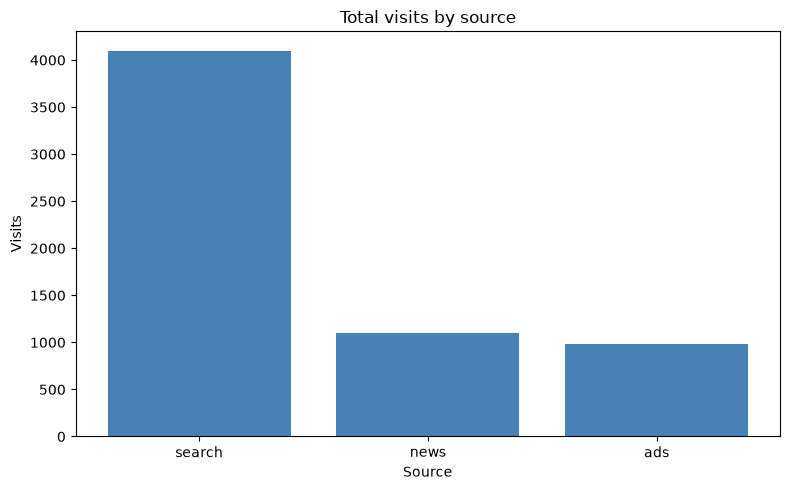

DuckDB + Pandas + Matplotlib demo OK.


In [2]:
# SQL + DuckDB + Matplotlib demo

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

csv_path = Path.cwd().resolve()
for root in [Path.cwd().resolve(), Path.cwd().resolve().parent, Path.cwd().resolve().parent.parent]:
    candidate = root / 'data' / 'notebook_env_demo.csv'
    if candidate.exists():
        csv_path = candidate
        break

source_df = pd.read_csv(csv_path)
print('Loaded rows:', len(source_df))
print(source_df.head())

con = duckdb.connect(database=':memory:')
con.register('traffic', source_df)
summary_df = con.execute('''
    SELECT source,
           SUM(visits) AS total_visits,
           AVG(conversion) AS avg_conversion
    FROM traffic
    GROUP BY source
    ORDER BY total_visits DESC
''').fetchdf()

print('\nSQL summary:')
print(summary_df)

plt.figure(figsize=(8, 5))
plt.bar(summary_df['source'], summary_df['total_visits'], color='steelblue')
plt.title('Total visits by source')
plt.xlabel('Source')
plt.ylabel('Visits')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('DuckDB + Pandas + Matplotlib demo OK.')